In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from cns.process import *
from cns.display import * 
from cns.utils import *
from cns.data_utils import *

In [4]:
pcawg_cns_df = add_total_cn(load_cns_out("PCAWG_cns_imp.tsv"))
pcawg_cns_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn
0,SP101724,chr1,0,27256755,2,2,4
1,SP101724,chr1,27256755,28028200,3,2,5
2,SP101724,chr1,28028200,32976095,2,2,4
3,SP101724,chr1,32976095,33354394,5,2,7
4,SP101724,chr1,33354394,33554783,3,2,5


In [20]:
genes_segs = load_segs_out("segs_COSMIC.bed")

pcawg_1_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 1), 100_000)
pcawg_1_groups_df = group_samples(pcawg_1_bin_df, group_name="100 kb")

pcawg_10_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 10), 1_000_000)
pcawg_10_groups_df = group_samples(pcawg_10_bin_df, group_name="1 mb")

pcawg_50_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 50), 10_000_000)
pcawg_50_groups_df = group_samples(pcawg_50_bin_df, group_name="10 mb")

pcawg_arms_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 10), "arms")
pcawg_arms_groups_df = group_samples(pcawg_arms_bin_df, group_name="arms")

gene_bin_df = aggregate_by_segments(cns_head(pcawg_cns_df, 10), genes_segs)
gene_groups_df = group_samples(gene_bin_df, group_name="COSMIC")

Aggregated into 30363 CNS.                                        
Aggregated into 30399 CNS.                                        
Aggregated into 15256 CNS.                                        
Aggregated into 462 CNS.                                        
Aggregated into 7220 CNS.                                        


# Plots

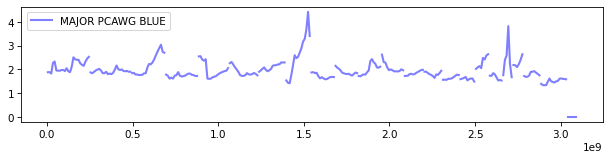

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_lines(ax, pcawg_50_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

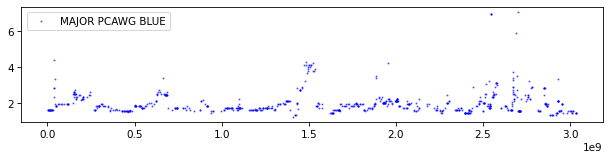

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_dots(ax, gene_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 1)
ax.legend()

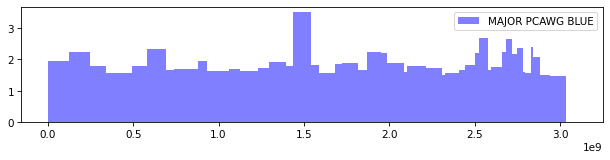

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_bars(ax, pcawg_arms_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5)
ax.legend()

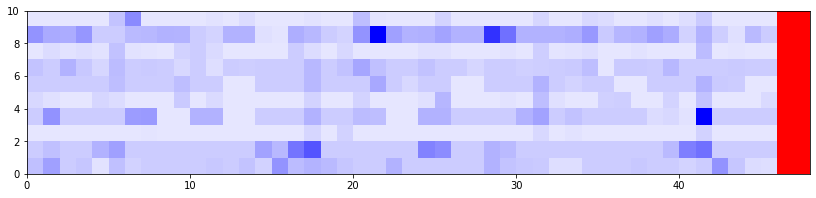

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(24, 3))
plot_CN_heatmap(ax, pcawg_arms_bin_df, "major_cn");

# Figures

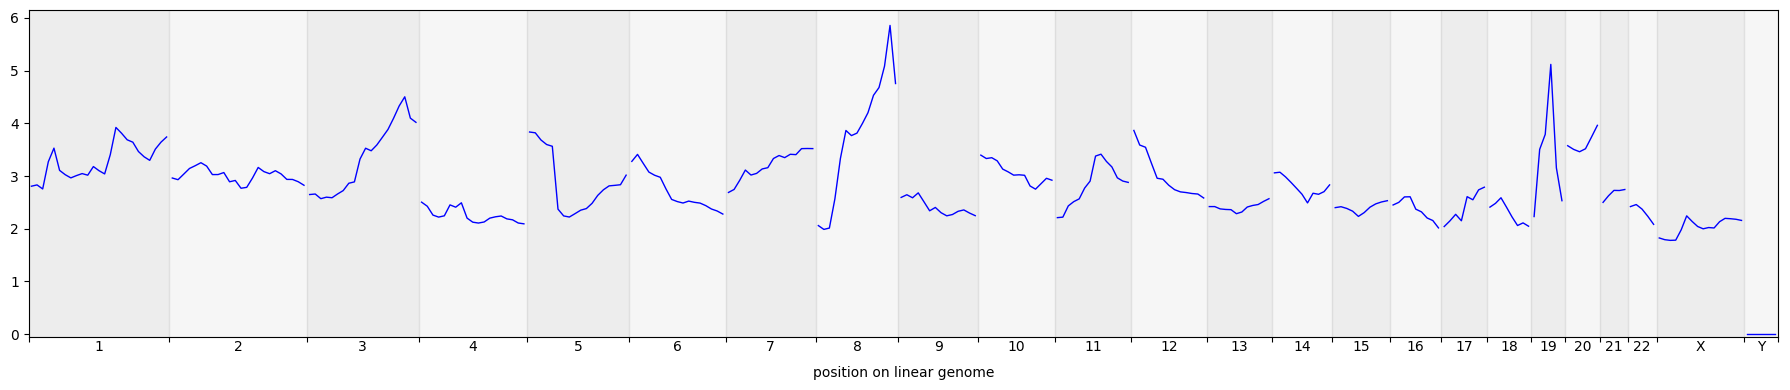

In [ ]:
fig_lines(pcawg_50_groups_df, cn_columns="total_cn", colors="blue");
save_doc_fig("fig_lines")

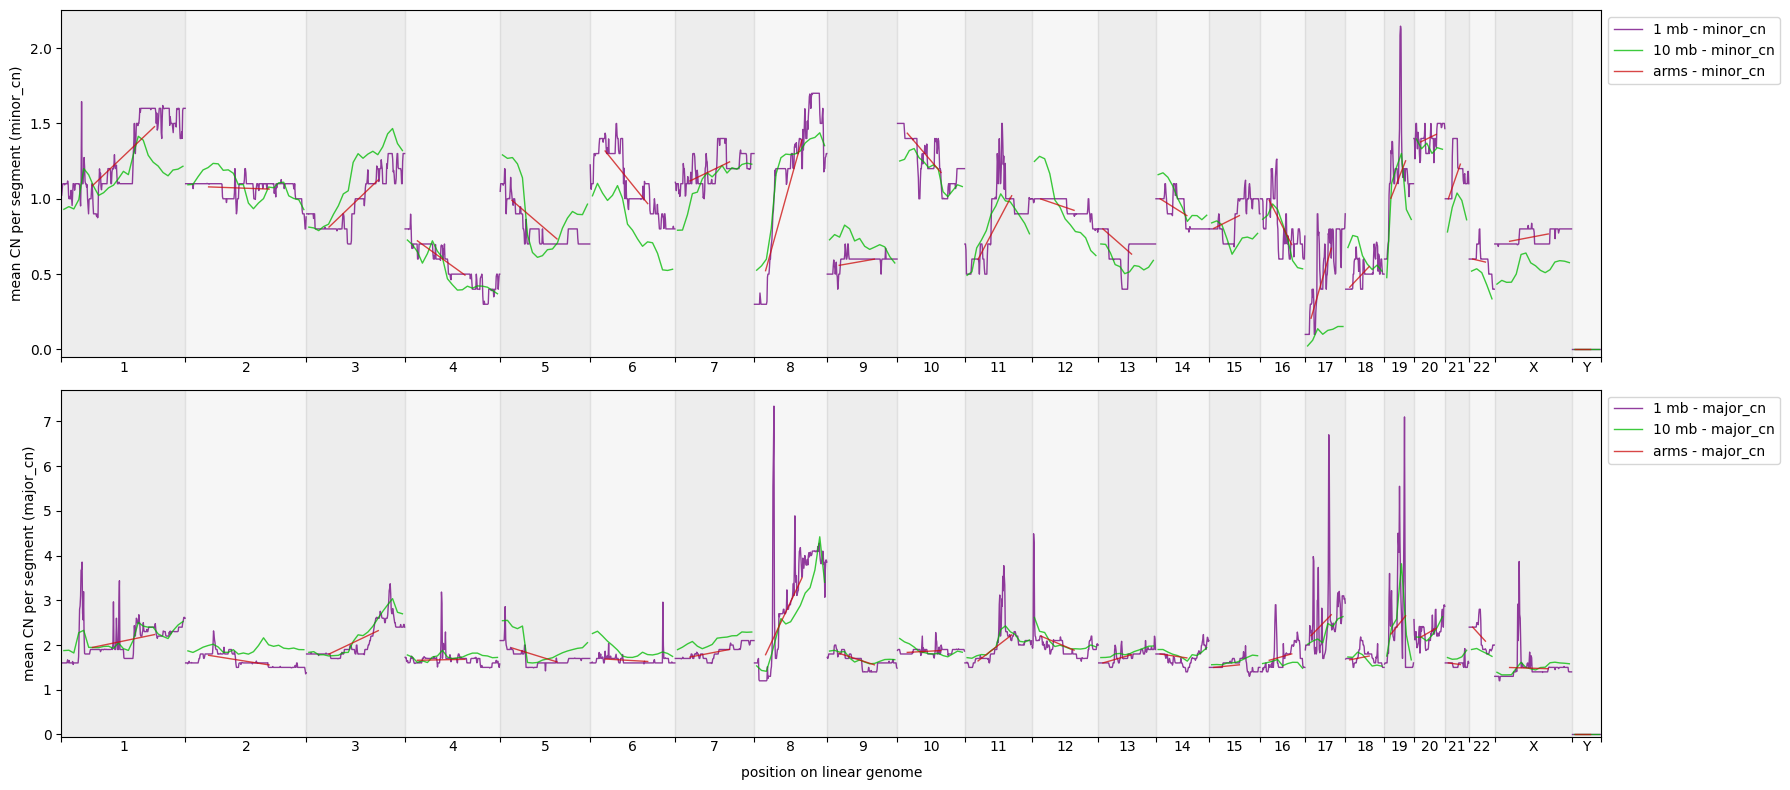

In [95]:
groups_df = pd.concat([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df])
fig_lines(groups_df, cn_columns=["minor_cn", "major_cn"]);
save_doc_fig("fig_lines_group")

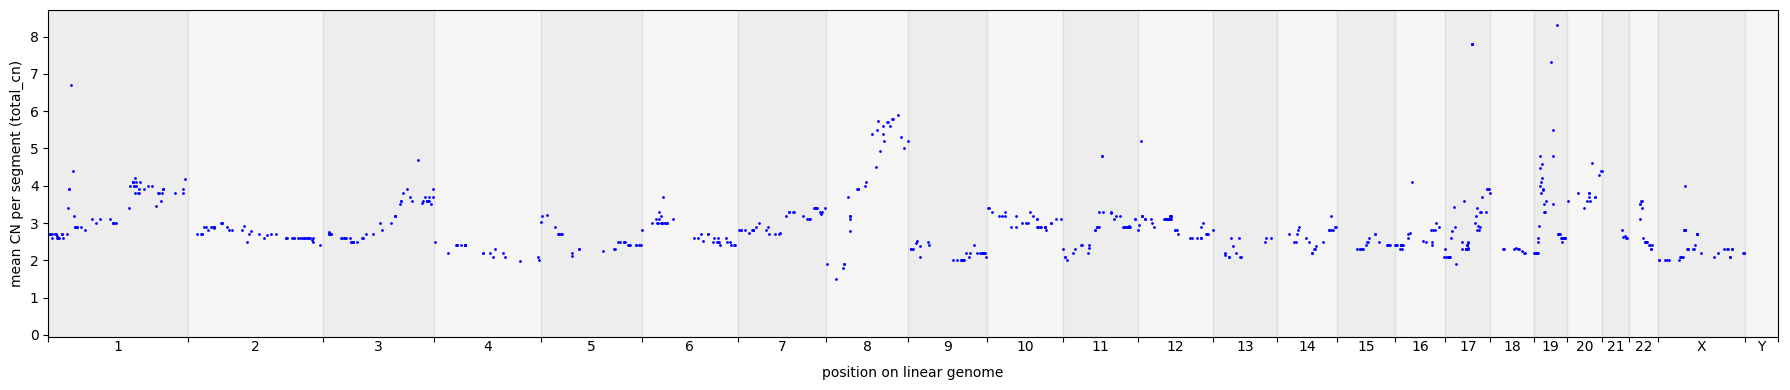

In [88]:
fig_dots(gene_groups_df, cn_columns="total_cn");
save_doc_fig("fig_dots")

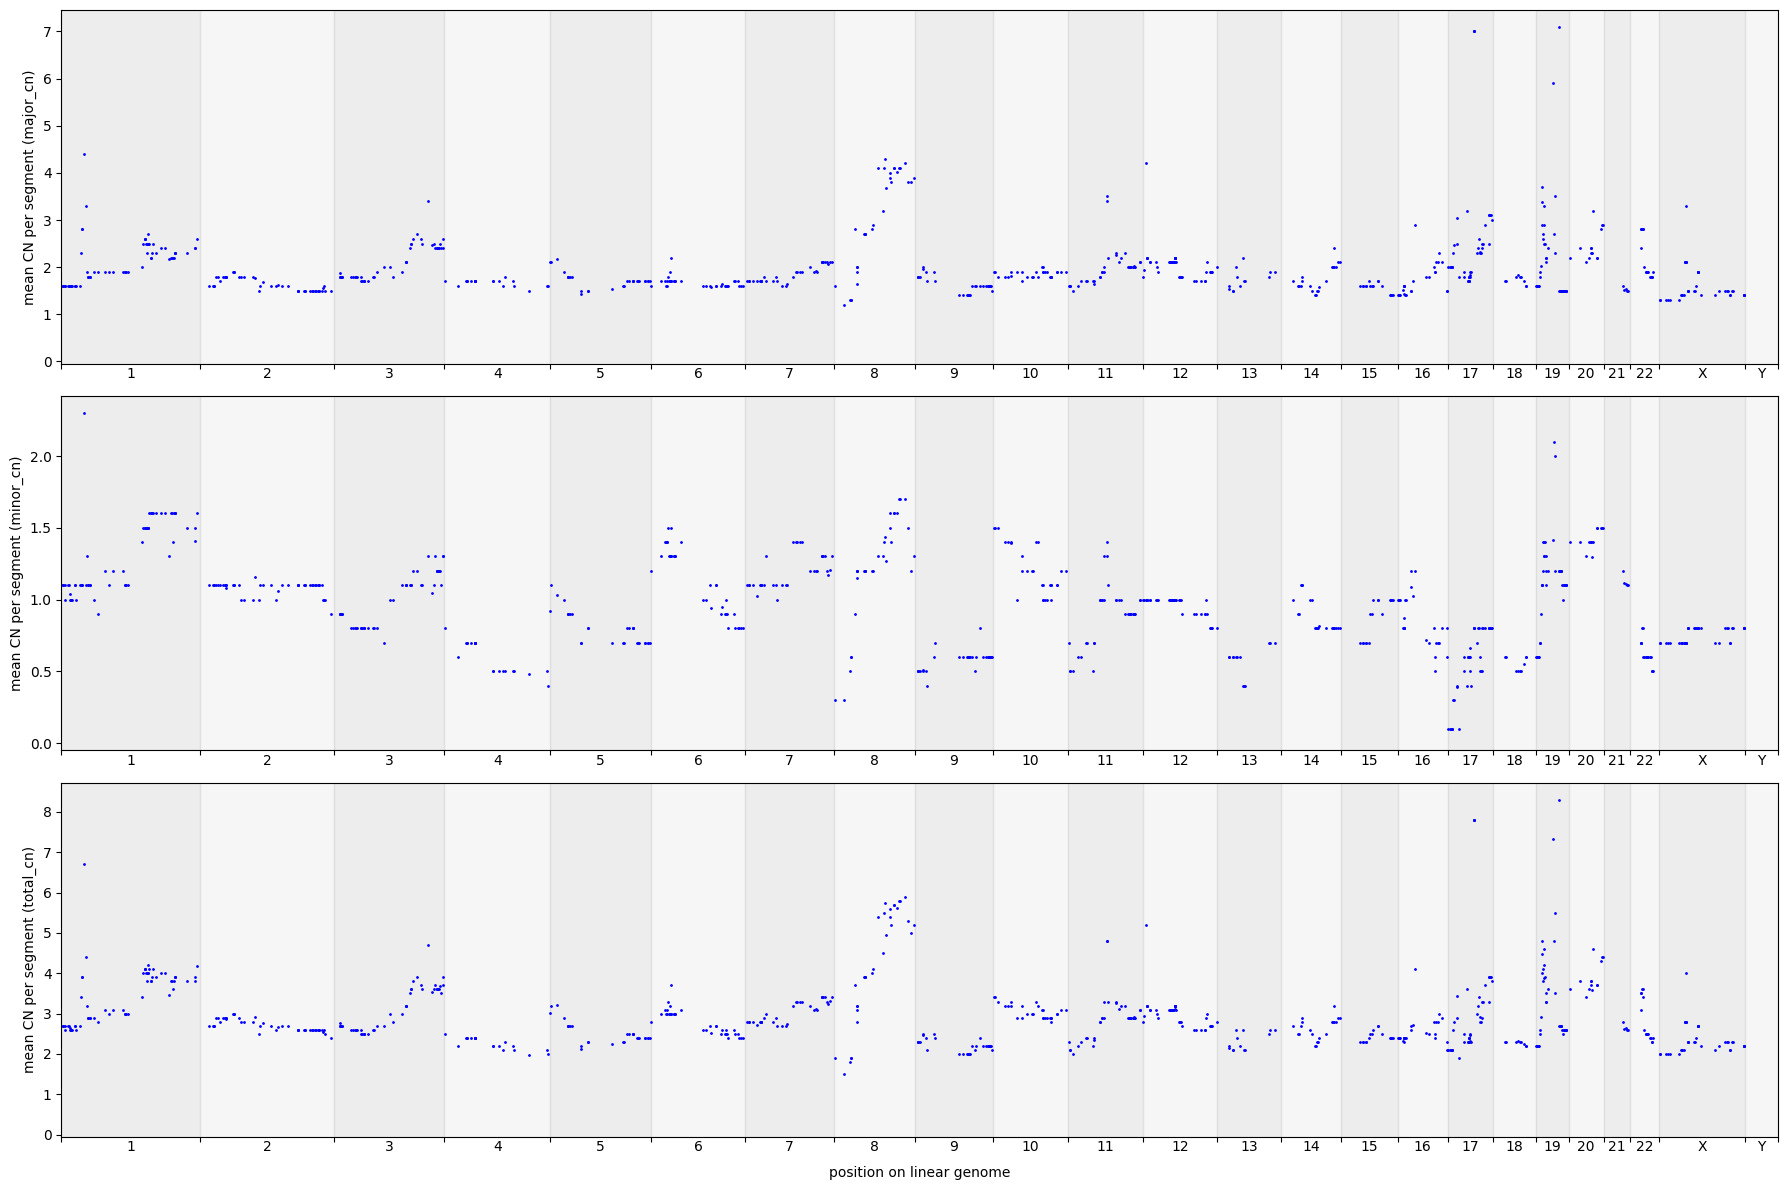

In [89]:
fig_dots(gene_groups_df)
save_doc_fig("fig_dots_group")

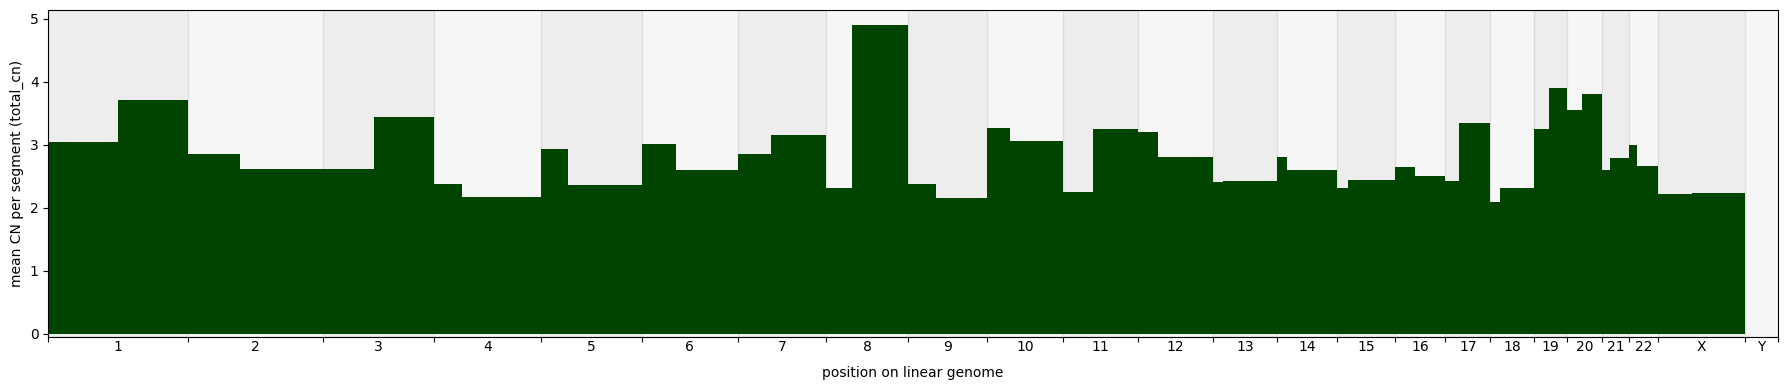

In [93]:
fig_bars(pcawg_arms_groups_df, cn_columns="total_cn", colors="#004400");
save_doc_fig("fig_bars")

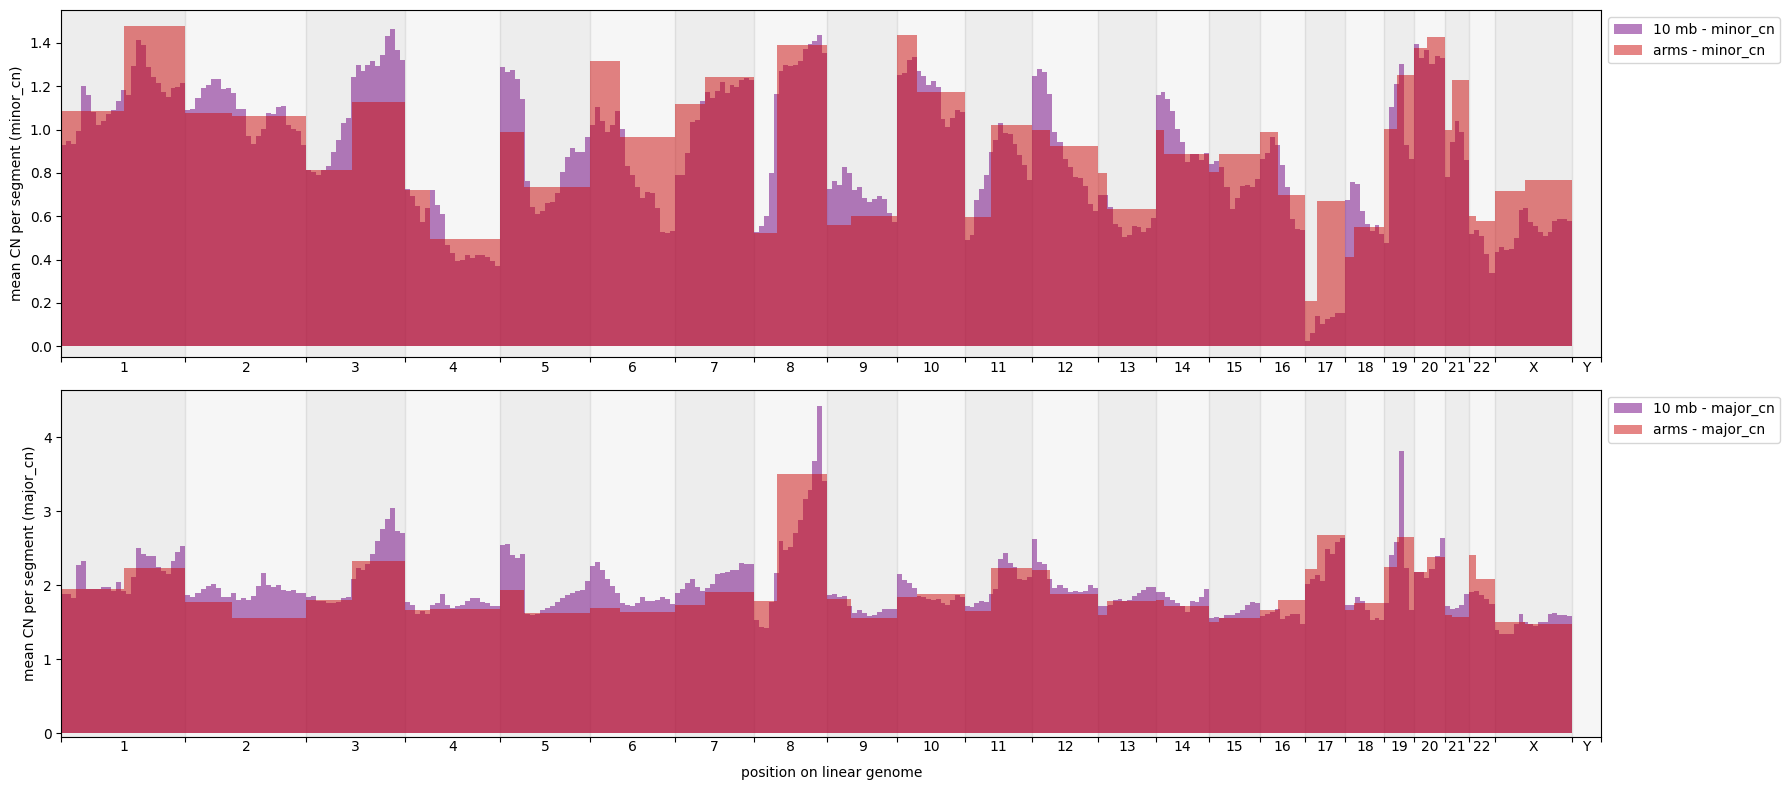

In [94]:
big_groups = pd.concat([pcawg_50_groups_df, pcawg_arms_groups_df])
fig_bars(big_groups, cn_columns=["minor_cn", "major_cn"])
save_doc_fig("fig_bars_group")

## Single Chrom Only

In [80]:
step_size = int(1e6)
# only keep gaps at least half the step size
gaps_hg19_segs = tuples_to_segments(hg19.gaps)
genome_segs = genome_to_segments(hg19)
merged_hg19_gaps = merge_segments(gaps_hg19_segs)
filtered_gaps = filter_min_size(merged_hg19_gaps, step_size // 2)
filtered_genome = segment_difference(genome_segs, filtered_gaps)
filtered_segs = split_segments(filtered_genome, step_size)
filtered_cns = aggregate_by_segments(cns_head(pcawg_cns_df, 10), filtered_segs)

Aggregated into 28577 CNS.                                        


Text(0.5, 1.0, 'Mean Copy Number across the genome, gaps removed')

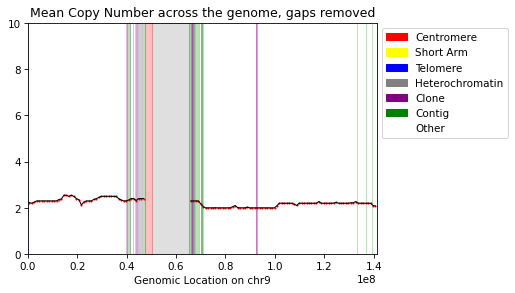

In [81]:
grouped_bins = group_samples(filtered_cns)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=75)
plot_gaps(ax, alpha=.25, y_max=10, chrom="chr9")
add_gap_legend(ax)
plot_lines(ax, grouped_bins, "total_cn", color="black", chrom="chr9")
plot_dots(ax, grouped_bins, "total_cn", color="red", chrom="chr9")
# no_y_ticks(ax)
# add lables
ax.set_xlabel("Genomic Location on chr9")
# ax.set_ylabel("Mean Copy Number")
ax.set_title("Mean Copy Number across the genome, gaps removed")

# CN Heatmaps

Figure size in inches: [18.    1.36] (Width x Height)
Ax size in inches: [17.7         0.87411502] (Width x Height)
Ax coordinates within the figure:
	Left: 0.00833333333333336
	Bottom: 0.17863418354818456
	Right: 0.9916666666666667
	Top: 0.8213658164518154
image_pixes:  [(607, 30363)]
dpi:  100
Top size:  0.1323529411764706


(<Figure size 1800x136 with 2 Axes>,
 <Axes: xlabel='total_cn', ylabel='sample'>)

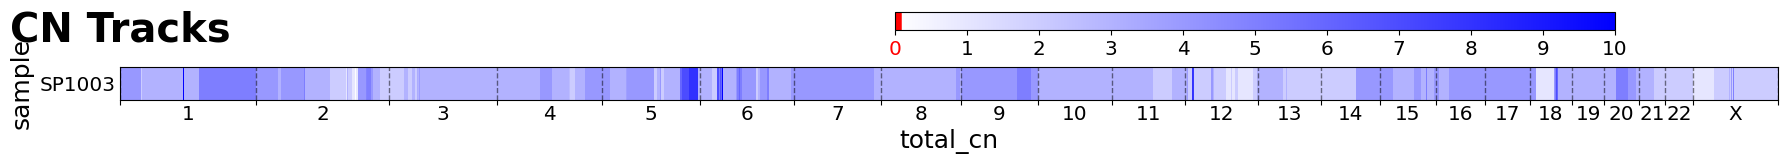

In [16]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True, column="total_cn", max_cn=10)

Aggregated into 554 CNS.                                        


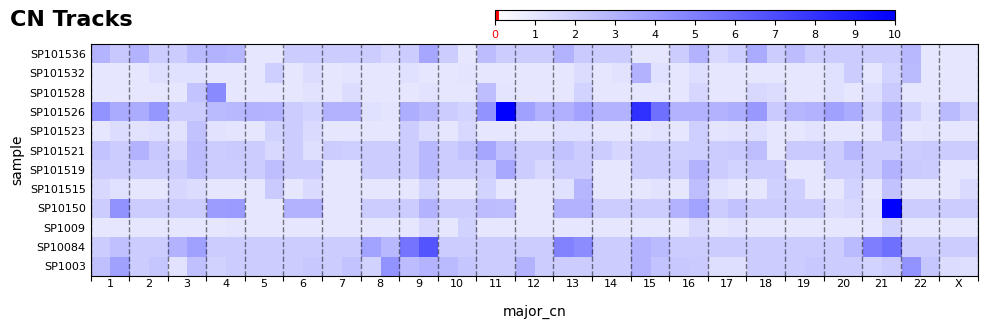

In [17]:
subset_arms = aggregate_by_break_type(cns_head(pcawg_cns_df, 12), "arms", hg19)
drop_Y(subset_arms, inplace=True)
fig_CN_heatmap(subset_arms, width=10, column="major_cn")
save_doc_fig("heatmap_arms.png")

Figure size in inches: [6. 5.] (Width x Height)
Ax size in inches: [0.90338194 4.7       ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.27415451388888873
	Bottom: 0.02999999999999997
	Right: 0.7258454861111112
	Top: 0.97
image_pixes:  [(10, 2), (10, 2), (10, 2)]
dpi:  100
Top size:  0.04


(<Figure size 600x500 with 4 Axes>,
 array([<Axes: xlabel='major_cn', ylabel='sample'>,
        <Axes: xlabel='minor_cn'>, <Axes: xlabel='total_cn'>], dtype=object))

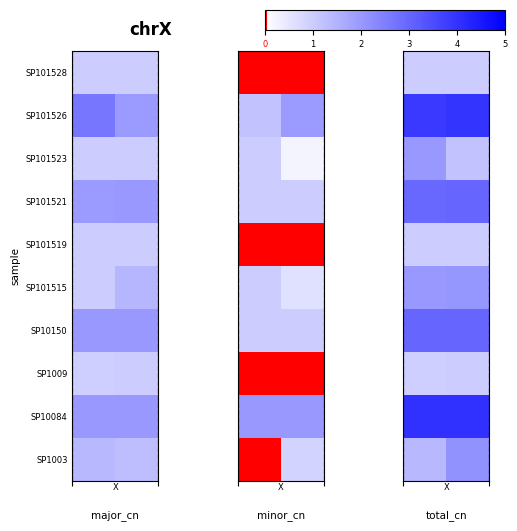

In [18]:
fig_CN_heatmap(pcawg_arms_bin_df, chrom="chrX", label="chrX", print_info=True, max_cn=10)

Figure size in inches: [16.   2.6] (Width x Height)
Ax size in inches: [7.46010417 1.88846801] (Width x Height)
Ax coordinates within the figure:
	Left: 0.03374348958333351
	Bottom: 0.1368330745293343
	Right: 0.9662565104166665
	Top: 0.8631669254706658
image_pixes:  [(620, 3093), (620, 3093)]
dpi:  100
Top size:  0.03076923076923077


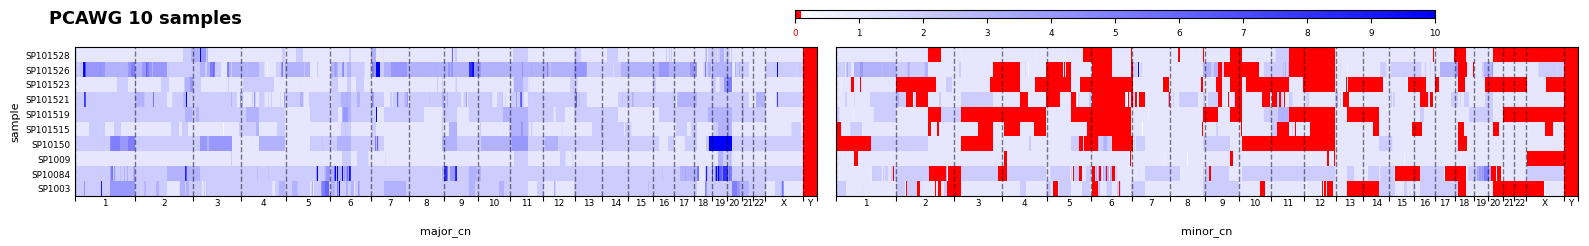

In [19]:
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG 10 samples", width=16, column=["major_cn", "minor_cn"], max_cn=10, print_info=True)
# save to ../../docs/tracks.png
plt.savefig(pjoin(docs_path, "tracks.png"), dpi=300)

(<Figure size 700x800 with 2 Axes>, <Axes: xlabel='total_cn', ylabel='sample'>)

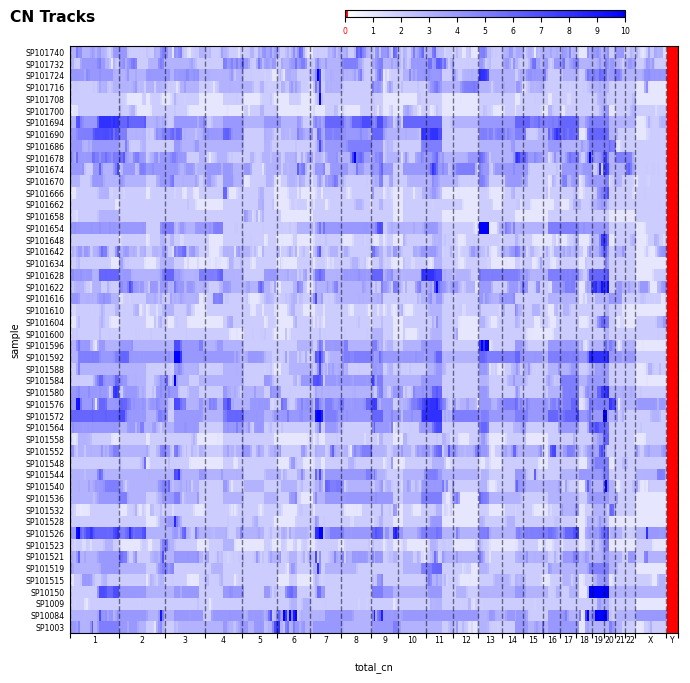

In [20]:
fig_CN_heatmap(pcawg_50_bin_df, width=7, column="total_cn", max_cn=10)

In [21]:
# pcawg_500_bin_df = bin_by_break_type(cns_head(pcawg_cns_df, 500), 10_000_000)
# print("Creating heatmap.... ")
# fig_CN_heatmap(pcawg_500_bin_df, column="total_cn");